
# AI Jobs Market 2025–2026 — Exploratory Data Analysis

This notebook performs **industry-grade exploratory data analysis (EDA)** on the AI Jobs Market dataset.

Goals:

- Understand **salary distribution**
- Analyze **experience vs salary**
- Identify **top-paying roles**
- Discover **skills and industry trends**
- Prepare insights for **machine learning modeling**


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

sns.set_style("whitegrid")

plt.rcParams.update({
    "figure.figsize": (14,6),
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "axes.titleweight": "bold",
    "font.size": 12
})

def currency(x, pos):
    return f"${int(x/1000)}K"

formatter = FuncFormatter(currency)


## Load Dataset

In [ ]:

DATA_PATH = "data/ai_jobs_market_2025_2026.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()


Shape: (1500, 25)


,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


## Dataset Overview

In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 1500 non-null   object 
 1   job_title              1500 non-null   object 
 2   job_category           1500 non-null   object 
 3   experience_level       1500 non-null   object 
 4   years_of_experience    1500 non-null   int64  
 5   education_required     1500 non-null   object 
 6   annual_salary_usd      1500 non-null   float64
 7   salary_min_usd         1500 non-null   int64  
 8   salary_max_usd         1500 non-null   int64  
 9   city                   1500 non-null   object 
 10  country                1500 non-null   object 
 11  remote_work            1500 non-null   object 
 12  company_size           1500 non-null   object 
 13  industry               1500 non-null   object 
 14  required_skills        1500 non-null   object 
 15  ai_s

In [4]:

df.describe()


,years_of_experience,annual_salary_usd,salary_min_usd,salary_max_usd,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,6.216000,194892.000000,135448.666667,257537.333333,10.858200,87.523333,31.116333,7.897333,2025.584000,3.968000,0.496667,0.754000,0.218000
std,2.675216,66506.822013,24448.950878,39852.822207,4.029742,8.026315,22.046343,1.102846,0.493058,3.270388,0.500156,0.430822,0.413025
min,1.000000,90000.000000,90000.000000,180000.000000,3.000000,68.000000,5.000000,6.000000,2025.000000,1.000000,0.000000,0.000000,0.000000
25%,4.000000,144750.000000,120000.000000,218000.000000,8.200000,82.000000,15.375000,6.900000,2025.000000,2.000000,0.000000,1.000000,0.000000
50%,6.000000,180000.000000,140000.000000,270000.000000,10.500000,89.000000,23.400000,7.900000,2026.000000,3.000000,0.000000,1.000000,0.000000
75%,8.000000,236250.000000,155000.000000,290000.000000,14.200000,95.000000,42.700000,8.900000,2026.000000,5.000000,1.000000,1.000000,0.000000
max,15.000000,384000.000000,180000.000000,320000.000000,18.000000,98.000000,87.800000,9.800000,2026.000000,12.000000,1.000000,1.000000,1.000000


## 1. Salary Distribution

c:\Users\srinithya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


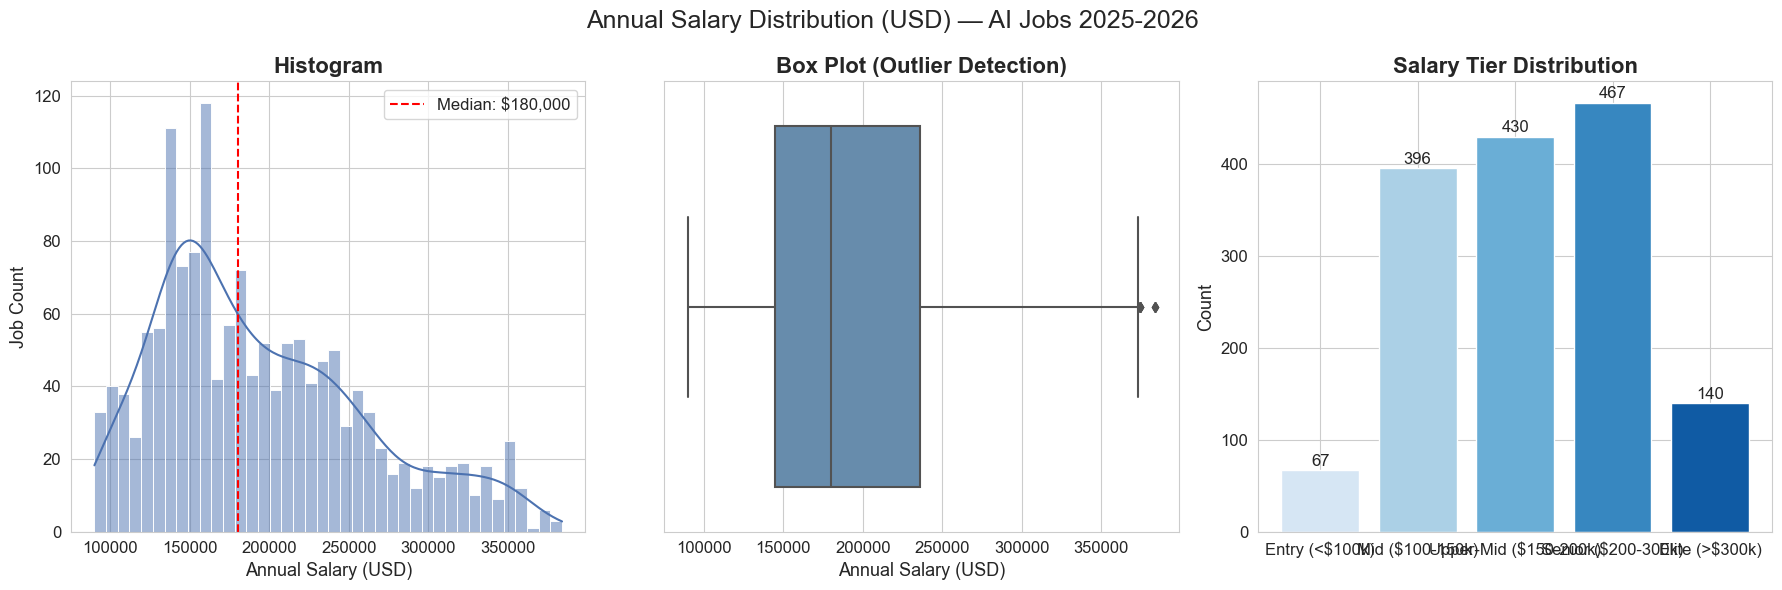

In [22]:
fig, axes = plt.subplots(1,3, figsize=(18,6))

salary = df["annual_salary_usd"]
median_salary = salary.median()

# Histogram
sns.histplot(salary, bins=40, kde=True, ax=axes[0], color="#4C72B0")
axes[0].axvline(median_salary, color="red", linestyle="--", label=f"Median: ${median_salary:,.0f}")
axes[0].set_title("Histogram")
axes[0].set_xlabel("Annual Salary (USD)")
axes[0].set_ylabel("Job Count")
axes[0].legend()

# Boxplot
sns.boxplot(x=salary, ax=axes[1], color="#5B8DB8")
axes[1].set_title("Box Plot (Outlier Detection)")
axes[1].set_xlabel("Annual Salary (USD)")

# Salary tiers
bins = [0,100000,150000,200000,300000,1000000]
labels = ["Entry (<$100k)", "Mid ($100-150k)", "Upper-Mid ($150-200k)", "Senior ($200-300k)", "Elite (>$300k)"]

df["salary_tier"] = pd.cut(df["annual_salary_usd"], bins=bins, labels=labels)

tier_counts = df["salary_tier"].value_counts().sort_index()

bars = axes[2].bar(tier_counts.index, tier_counts.values,
                  color=sns.color_palette("Blues", len(tier_counts)))

axes[2].set_title("Salary Tier Distribution")
axes[2].set_ylabel("Count")

for bar in bars:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2, height + 5,
                 int(height), ha='center')

plt.suptitle("Annual Salary Distribution (USD) — AI Jobs 2025-2026", fontsize=18)
plt.tight_layout()
plt.show()


## 2. Salary Trend based on Experience Level


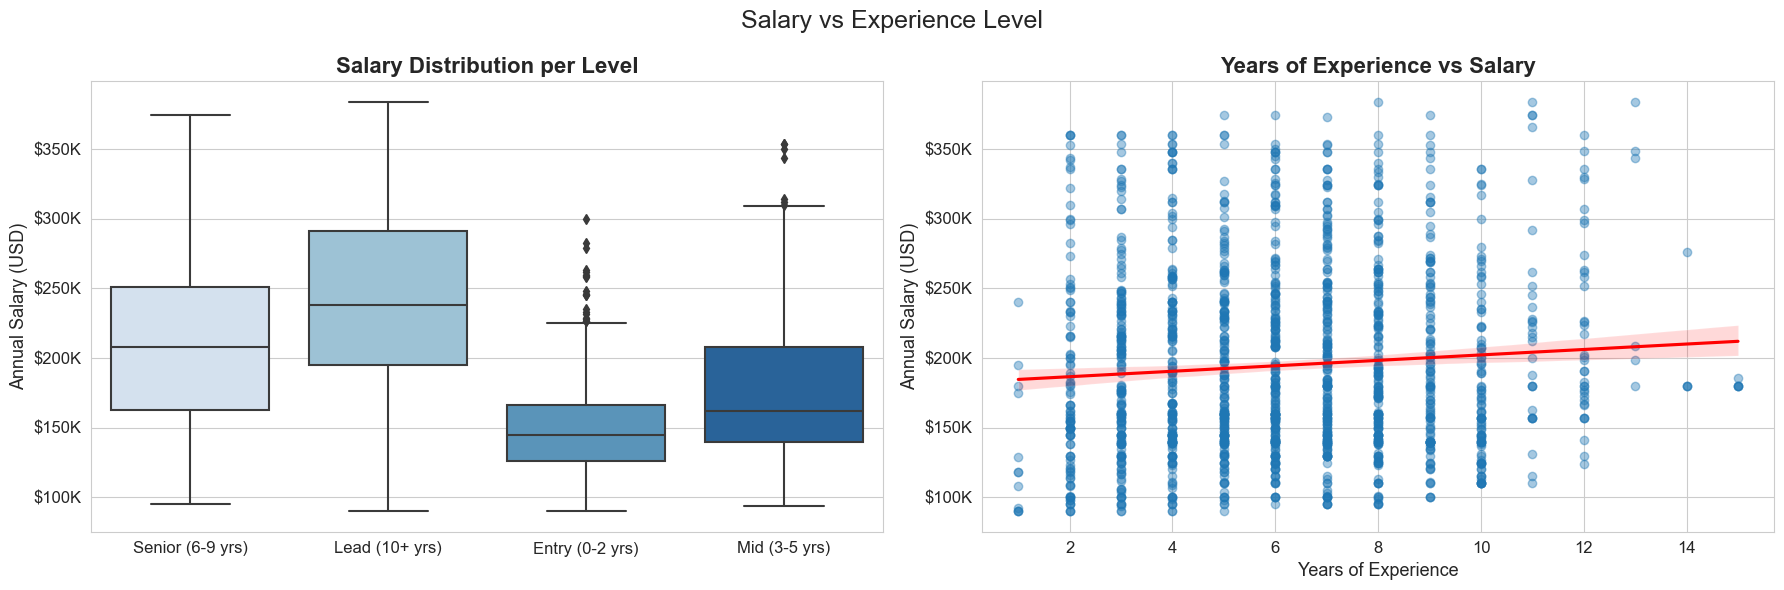

In [24]:
fig, axes = plt.subplots(1,2, figsize=(18,6))

# Salary by experience level
sns.boxplot(
    data=df,
    x="experience_level",
    y="annual_salary_usd",
    palette="Blues",
    ax=axes[0]
)

axes[0].set_title("Salary Distribution per Level")
axes[0].set_xlabel("")
axes[0].set_ylabel("Annual Salary (USD)")
axes[0].yaxis.set_major_formatter(formatter)

# Scatter + trend line
sns.regplot(
    data=df,
    x="years_of_experience",
    y="annual_salary_usd",
    scatter_kws={"alpha":0.4},
    line_kws={"color":"red"},
    ax=axes[1]
)

axes[1].set_title("Years of Experience vs Salary")
axes[1].set_xlabel("Years of Experience")
axes[1].set_ylabel("Annual Salary (USD)")
axes[1].yaxis.set_major_formatter(formatter)

plt.suptitle("Salary vs Experience Level", fontsize=18)
plt.tight_layout()
plt.show()

**Insight**

- Moving from a **Senior (6–9 yrs) to a Lead (10+ yrs) role** results in the most significant salary jump, with the median moving from roughly $210k to $240k.
- The scatter plot shows a very shallow regression line, which depicts that **years of experience alone do not dictate salary**.

## 3. Top AI Job Titles by Salary

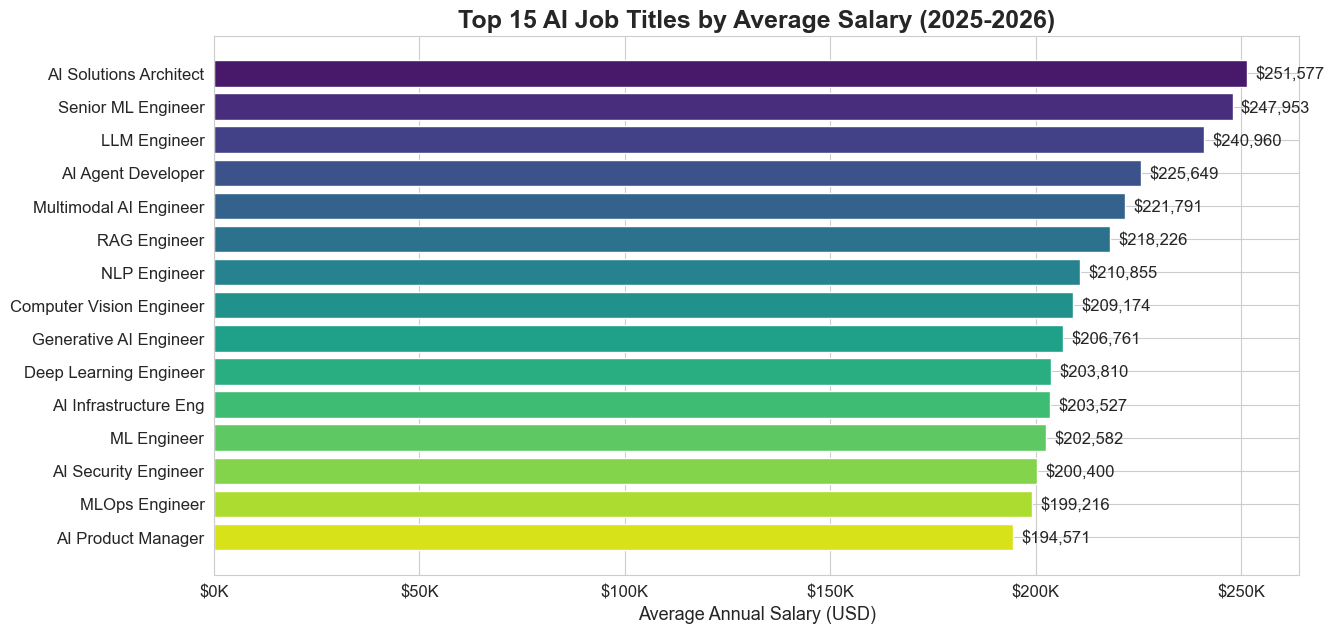

In [29]:
top_jobs = (
    df.groupby("job_title")["annual_salary_usd"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14,7))

colors = sns.color_palette("viridis", len(top_jobs))

bars = plt.barh(top_jobs.index, top_jobs.values, color=colors)

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(width + 2000,
             bar.get_y() + bar.get_height()/2,
             f"${width:,.0f}",
             va='center')

plt.title("Top 15 AI Job Titles by Average Salary (2025-2026)", fontsize=18)
plt.xlabel("Average Annual Salary (USD)")
plt.gca().xaxis.set_major_formatter(formatter)

plt.show()



**Insight**

- **Architects and LLM Specialists Command the Top Tier:** The AI Solutions Architect ($251,577) and LLM Engineer ($240,960) positions represent the absolute ceiling for technical roles.
-  Remarkably, 13 of the top 15 AI job titles now average over $200,000 annually.

## 4. Job Category Analysis

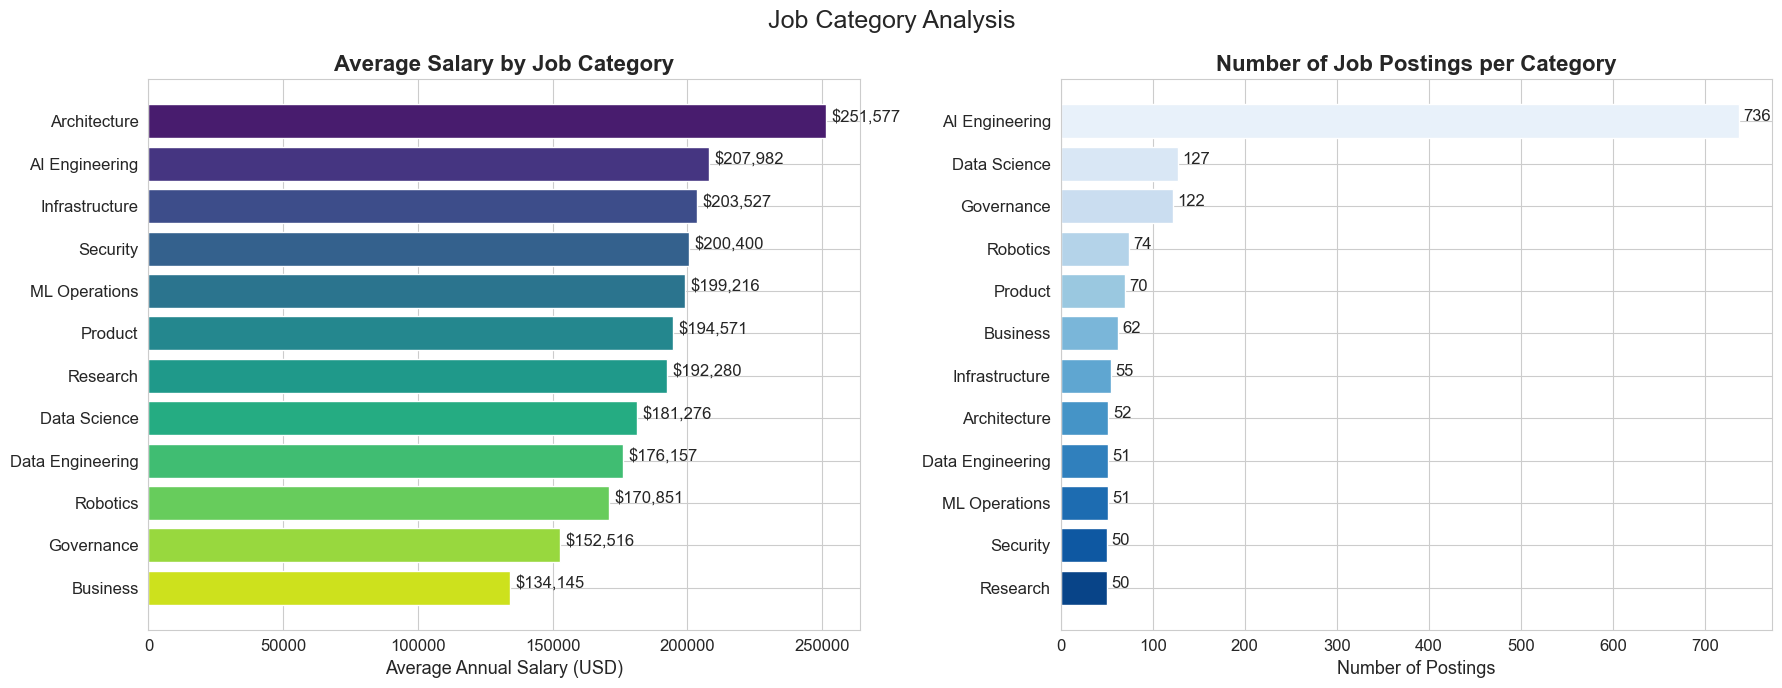

In [30]:

fig, axes = plt.subplots(1,2, figsize=(18,7))

# Average salary
avg_salary = df.groupby("job_category")["annual_salary_usd"].mean().sort_values(ascending=False)

bars = axes[0].barh(avg_salary.index, avg_salary.values,
                    color=sns.color_palette("viridis", len(avg_salary)))

axes[0].invert_yaxis()
axes[0].set_title("Average Salary by Job Category")
axes[0].set_xlabel("Average Annual Salary (USD)")

for bar in bars:
    val = bar.get_width()
    axes[0].text(val + 2000, bar.get_y() + bar.get_height()/2, f"${val:,.0f}")

# Job postings
counts = df["job_category"].value_counts()

bars2 = axes[1].barh(counts.index, counts.values,
                     color=sns.color_palette("Blues", len(counts)))

axes[1].invert_yaxis()
axes[1].set_title("Number of Job Postings per Category")
axes[1].set_xlabel("Number of Postings")

for bar in bars2:
    val = bar.get_width()
    axes[1].text(val + 5, bar.get_y() + bar.get_height()/2, int(val))

plt.suptitle("Job Category Analysis", fontsize=18)

plt.tight_layout()
plt.show()


**Insight**

- AI Engineering is the undisputed leader in volume with 736 postings—nearly 6x more than the second-place category (Data Science). It effectively balances high demand with a top-tier average salary ($207,982)

## 5. LLM Roles vs Non-LLM Roles

- Large Language Models (LLMs) are currently the fastest-growing area in AI.
- Goal: Determine whether specializing in **LLM engineering provides a salary advantage.**

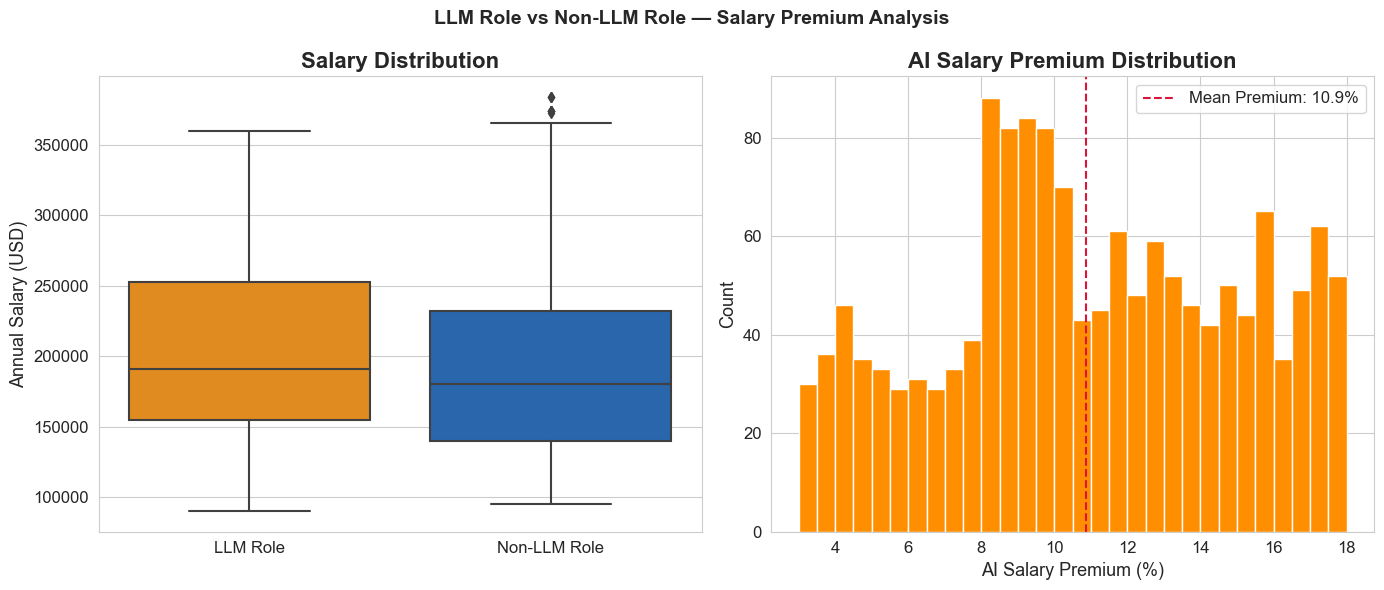

In [34]:
df["role_type"] = df["is_llm_role"].map({1: "LLM Role", 0: "Non-LLM Role"})

fig, axes = plt.subplots(1,2, figsize=(14,6))
fig.suptitle("LLM Role vs Non-LLM Role — Salary Premium Analysis", fontsize=14, fontweight="bold")

# Boxplot
sns.boxplot(
    data=df,
    x="role_type",
    y="annual_salary_usd",
    palette=["#ff8f00","#1565c0"],
    ax=axes[0]
)

axes[0].set_title("Salary Distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("Annual Salary (USD)")

# Salary premium distribution
axes[1].hist(
    df["ai_salary_premium_pct"],
    bins=30,
    color="#ff8f00",
    edgecolor="white"
)

axes[1].axvline(
    df["ai_salary_premium_pct"].mean(),
    color="crimson",
    linestyle="--",
    label=f"Mean Premium: {df['ai_salary_premium_pct'].mean():.1f}%"
)

axes[1].set_title("AI Salary Premium Distribution")
axes[1].set_xlabel("AI Salary Premium (%)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

**Insight**

LLM-focused roles show a noticeable salary premium.

This trend reflects the surge in demand for:
- Generative AI systems
- Retrieval Augmented Generation (RAG)
- AI agent architectures

## 6. Geographic Salary Analysis

- AI salaries vary significantly by location.
- This insight helps professionals decide **where relocation or remote work could maximize compensation.**

In [37]:
country_stats = (df.groupby("country")["annual_salary_usd"].agg(["mean", "count"]).query("count >= 20").sort_values("mean", ascending=True).head(12))
print(country_stats)

                      mean  count
country                          
India        133122.807018     57
China        134287.356322     87
Japan        170131.578947     76
Netherlands  175256.756757     74
Canada       180588.235294     85
UK           180644.444444     90
Germany      181180.246914     81
Singapore    181830.985915     71
France       183151.515152     66
Australia    188000.000000     78
Switzerland  190592.105263     76
UAE          194225.806452     62


In [38]:
city_stats = (
    df.groupby("city")["annual_salary_usd"]
      .agg(["mean","count"])
      .query("count >= 15")
      .sort_values("mean",ascending=False)
      .head(12)
)
print(city_stats)

                        mean  count
city                               
New York       248659.701493     67
San Francisco  240521.739130     92
Seattle        230544.927536     69
Remote         222043.902439     82
Chicago        219511.688312     77
Boston         219400.000000     70
Los Angeles    216184.126984     63
Austin         206649.350649     77
Dubai          194225.806452     62
Zurich         190592.105263     76
Sydney         188000.000000     78
Paris          183151.515152     66


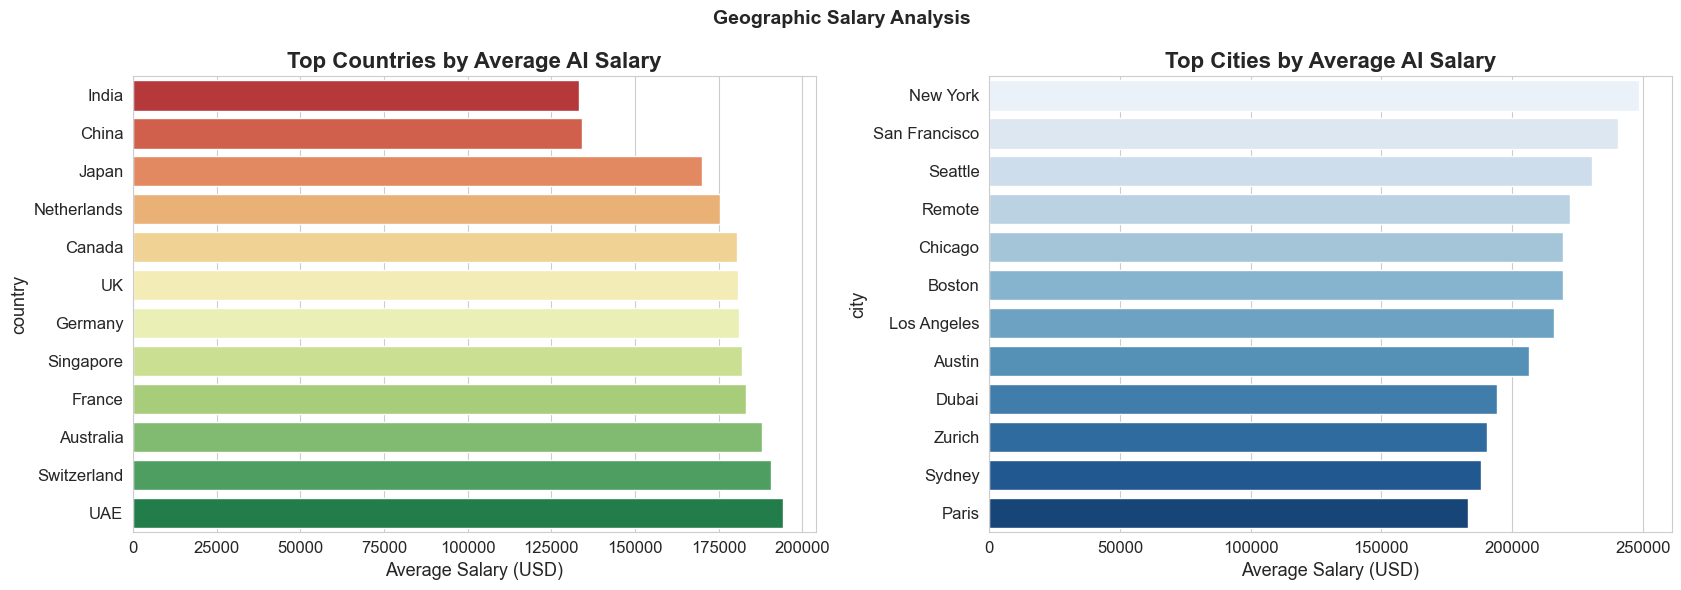

In [39]:

fig, axes = plt.subplots(1,2, figsize=(17,6))
fig.suptitle("Geographic Salary Analysis", fontsize=14, fontweight="bold")

sns.barplot(
    x=country_stats["mean"],
    y=country_stats.index,
    palette="RdYlGn",
    ax=axes[0]
)

axes[0].set_title("Top Countries by Average AI Salary")
axes[0].set_xlabel("Average Salary (USD)")

sns.barplot(
    x=city_stats["mean"],
    y=city_stats.index,
    palette="Blues",
    ax=axes[1]
)

axes[1].set_title("Top Cities by Average AI Salary")
axes[1].set_xlabel("Average Salary (USD)")

plt.tight_layout()
plt.show()

**Insight**

Countries with mature AI ecosystems tend to offer significantly higher compensation.

Major global AI hubs also attract companies willing to pay premium salaries for specialized talent.

## 7. Industry Salary Comparison

- AI roles exist across many industries, but compensation varies widely.
- This analysis shows which industries offer the **highest AI salaries**.

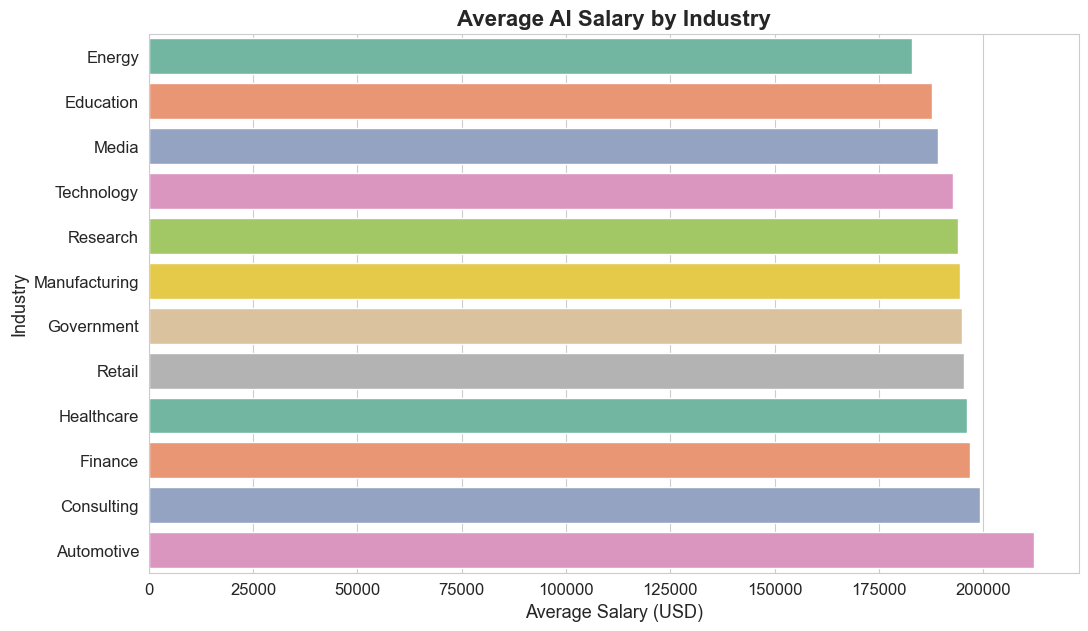

In [42]:
industry_stats = (
    df.groupby("industry")["annual_salary_usd"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(12,7))

sns.barplot(
    x=industry_stats.values,
    y=industry_stats.index,
    palette="Set2"
)

plt.title("Average AI Salary by Industry")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Industry")

plt.show()

**Insight**
- The "traditional" tech industry is no longer the highest payer for AI talent. To maximize your earning potential, you should look toward specialized engineering sectors (Automotive) or high-stakes service sectors (Consulting/Finance) where AI is being used to disrupt legacy business models.

## 8. Job Demand & Growth Analysis

- Not all AI roles grow at the same rate.
- Roles with **high demand and high growth** represent the best opportunities for newcomers.

In [43]:
top_growth = (
    df.groupby("job_title")
      .agg(
        demand=("demand_score","mean"),
        growth=("demand_growth_yoy_pct","mean"),
        salary=("annual_salary_usd","mean")
      )
      .sort_values("growth",ascending=False)
      .head(15)
)
print(top_growth)

                          demand     growth         salary
job_title                                                 
RAG Engineer                94.0  55.324528  218226.415094
NLP Engineer                91.0  54.694545  210854.545455
MLOps Engineer              93.0  52.819608  199215.686275
AI Engineer                 95.0  52.750000  159859.375000
ML Engineer                 97.0  52.645455  202581.818182
LLM Engineer                98.0  51.784000  240960.000000
AI Agent Developer          96.0  49.896491  225649.122807
Senior ML Engineer          96.0  49.017187  247953.125000
Generative AI Engineer      95.0  48.198592  206760.563380
Data Scientist              92.0  46.821311  173639.344262
Data Engineer (AI)          88.0  19.652941  176156.862745
Computer Vision Engineer    87.0  18.856522  209173.913043
AI Infrastructure Eng       85.0  18.398182  203527.272727
Robotics Engineer (AI)      76.0  18.067568  170851.351351
AI Solutions Architect      84.0  18.032692  251576.9230

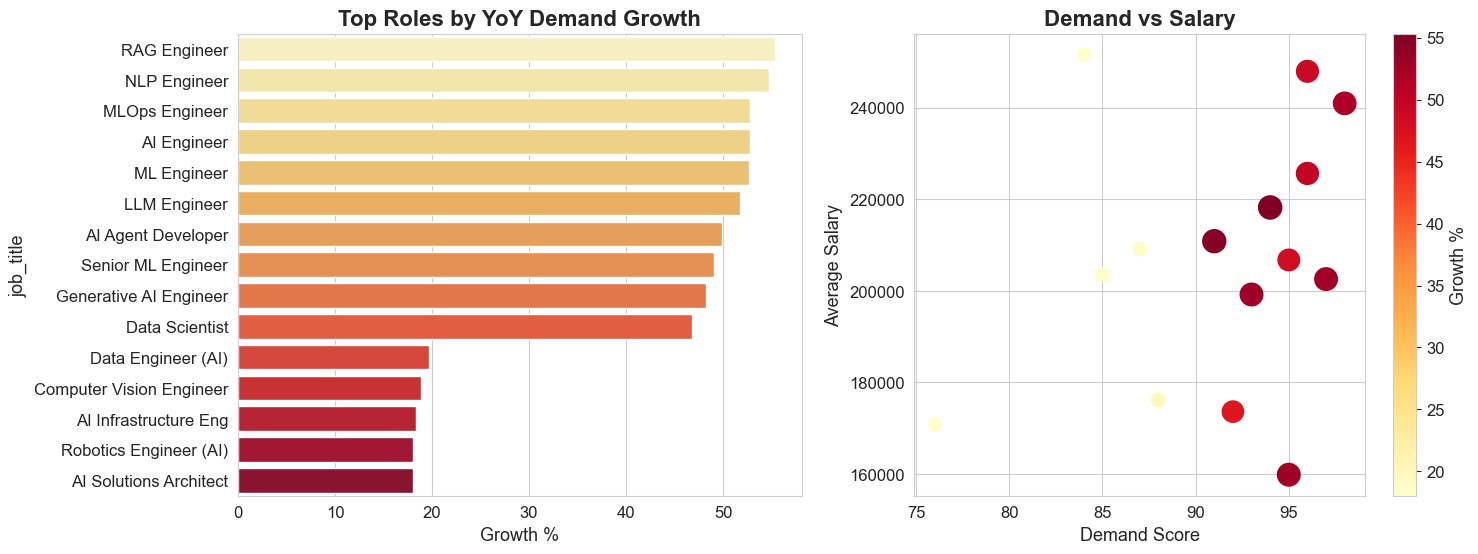

In [44]:
fig, axes = plt.subplots(1,2, figsize=(16,6))

sns.barplot(
    x=top_growth["growth"],
    y=top_growth.index,
    palette="YlOrRd",
    ax=axes[0]
)

axes[0].set_title("Top Roles by YoY Demand Growth")
axes[0].set_xlabel("Growth %")

scatter = axes[1].scatter(
    top_growth["demand"],
    top_growth["salary"],
    s=top_growth["growth"]*5,
    c=top_growth["growth"],
    cmap="YlOrRd"
)

axes[1].set_title("Demand vs Salary")
axes[1].set_xlabel("Demand Score")
axes[1].set_ylabel("Average Salary")

plt.colorbar(scatter,label="Growth %")

plt.show()

**Insight**

- **Specialization Pays Off**: Generic "AI Engineer" roles are strong, but hyper-specialized roles like RAG (Retrieval-Augmented Generation) Engineer are currently the fastest-growing niche in the market.
- **Market Maturity:** The high demand scores (90+) for high-salary roles indicate a "talent war" where companies are willing to pay a premium for specific expertise in LLMs and generative AI.


## 9. Skills Demand Analysis

Understanding skill demand helps professionals decide **what technologies to learn**.

This section identifies:
- Most frequently requested AI skills
- Skills associated with the highest salaries

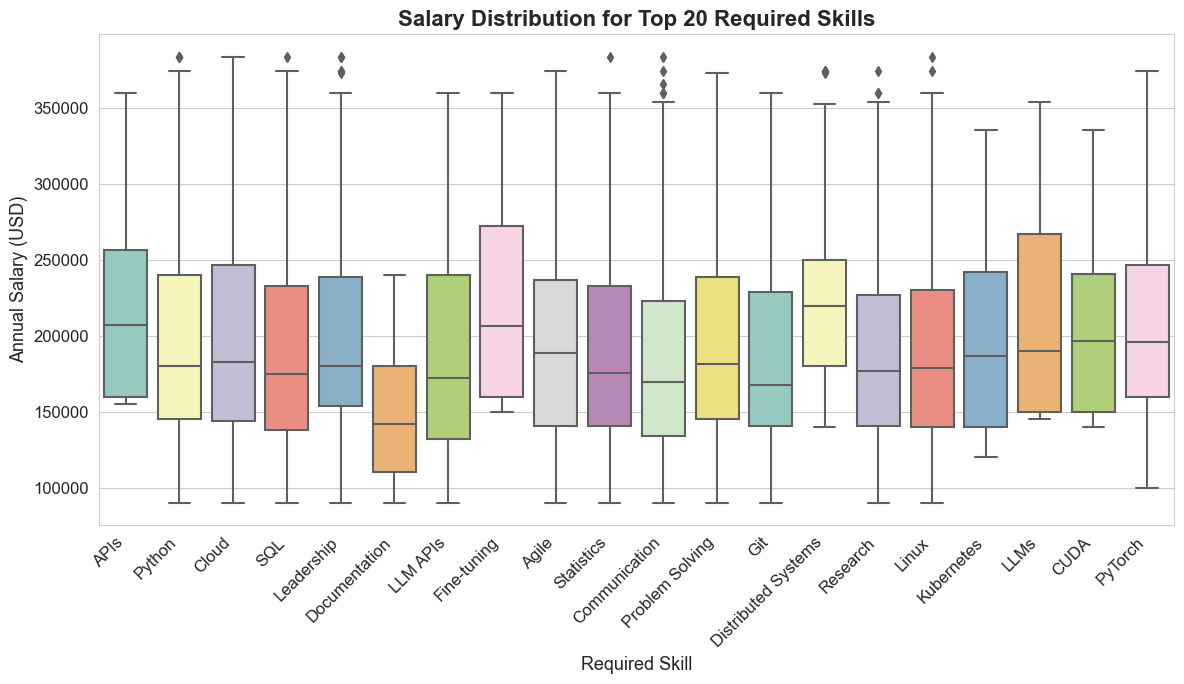

In [46]:
skills = df["required_skills"].dropna().str.split("|").explode()
top_skills = skills.value_counts().head(20)
plt.figure(figsize=(12,7))

skill_salary_df = pd.DataFrame({
    'skill': skills,
    'salary': df["annual_salary_usd"].repeat(df["required_skills"].str.split("|").str.len())
})
skill_salary_df = skill_salary_df[skill_salary_df['skill'].isin(top_skills.index)]

sns.boxplot(
    data=skill_salary_df,
    x="skill",
    y="salary",
    palette="Set3"
)

plt.title("Salary Distribution for Top 20 Required Skills")
plt.xlabel("Required Skill")
plt.ylabel("Annual Salary (USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Insight**

- **The Generative AI Premium:** Skills directly related to the LLM boom—Fine-tuning, LLMs, LLM APIs, and PyTorch—all show high medians and significant upward potential. Fine-tuning, in particular, has a very high "floor" compared to more general skills like Python or SQL.

- **"Soft" vs. "Hard" Skills:** Interestingly, Leadership and Distributed Systems have higher median salaries than many technical coding skills. This suggests that as you move up the pay scale, the ability to manage teams or complex architecture becomes more valuable than individual technical execution.

## 10. Remote Work & Company Size

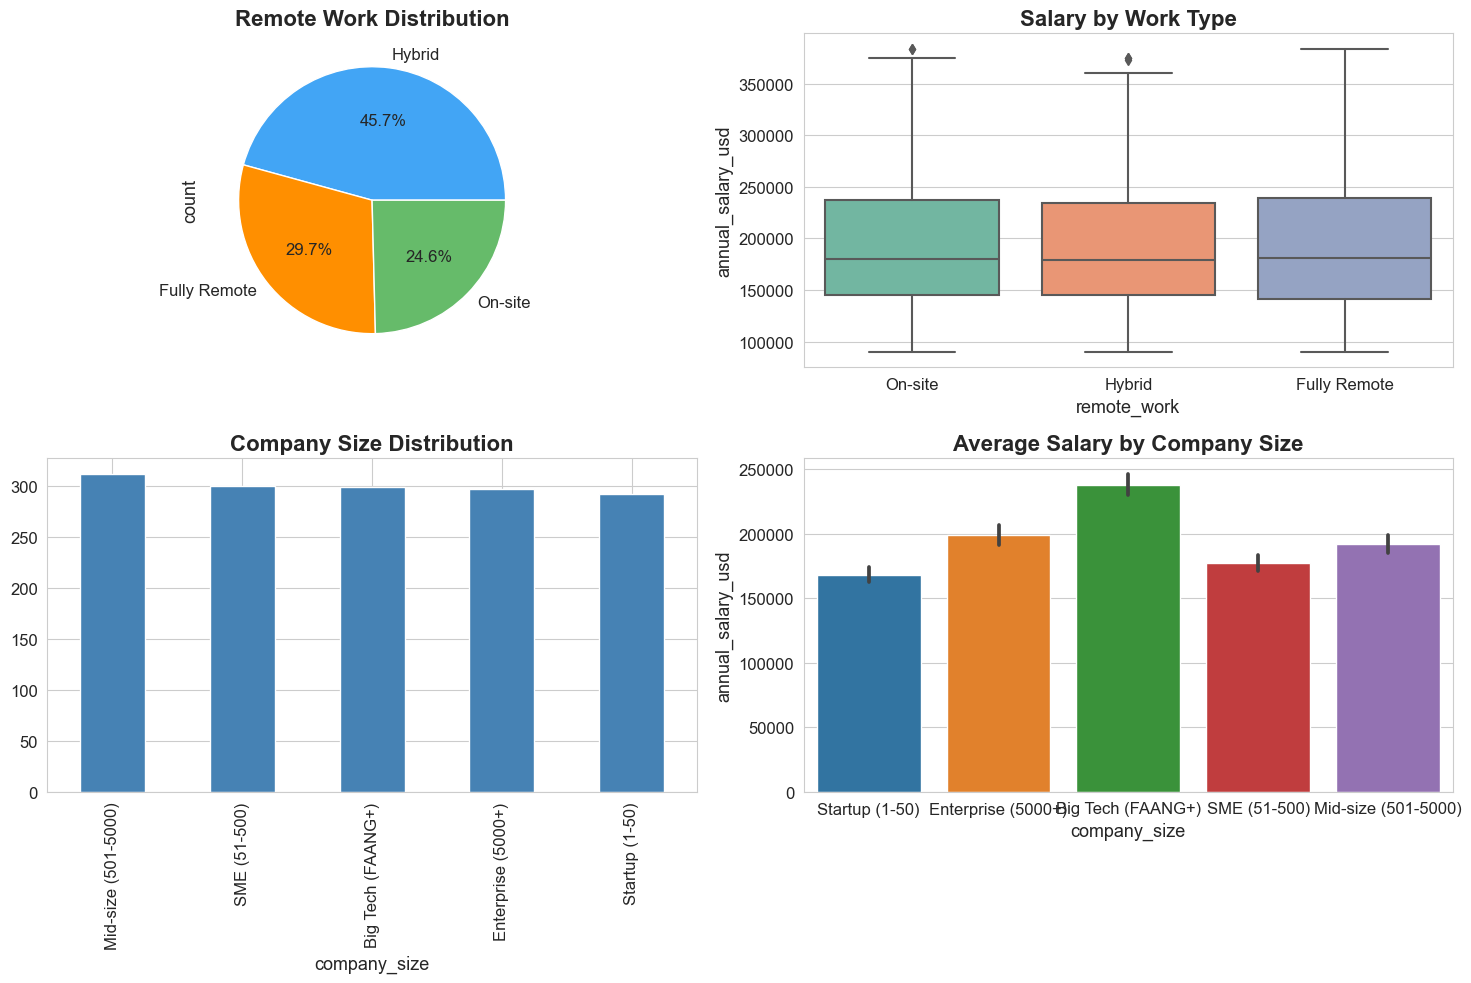

In [47]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

# Remote distribution
df["remote_work"].value_counts().plot.pie(
    autopct="%1.1f%%",
    ax=axes[0,0],
    colors=["#42a5f5","#ff8f00","#66bb6a"]
)

axes[0,0].set_title("Remote Work Distribution")

# Salary by remote type
sns.boxplot(
    data=df,
    x="remote_work",
    y="annual_salary_usd",
    palette="Set2",
    ax=axes[0,1]
)

axes[0,1].set_title("Salary by Work Type")

# Company size distribution
df["company_size"].value_counts().plot.bar(
    ax=axes[1,0],
    color="steelblue"
)

axes[1,0].set_title("Company Size Distribution")

# Salary by company size
sns.barplot(
    data=df,
    x="company_size",
    y="annual_salary_usd",
    estimator=np.mean,
    ax=axes[1,1]
)

axes[1,1].set_title("Average Salary by Company Size")

plt.tight_layout()
plt.show()

**Insight**

- **Flexibility is Free:** Since salaries are nearly identical across work types, you can prioritize your preferred lifestyle (Remote vs. On-site) without a significant ***pay penalty***.
- **Mid-Size Great Spot:** If you aren't at a FAANG company, ***Enterprise and Mid-size*** companies offer the next best compensation, often outperforming SMEs and Startups in base pay.
- **Stability vs. Risk:** Big Tech offers the highest guaranteed cash, while Startups likely rely on the "upside" of growth to attract talent despite lower immediate salaries.

## 11. Education vs Salary

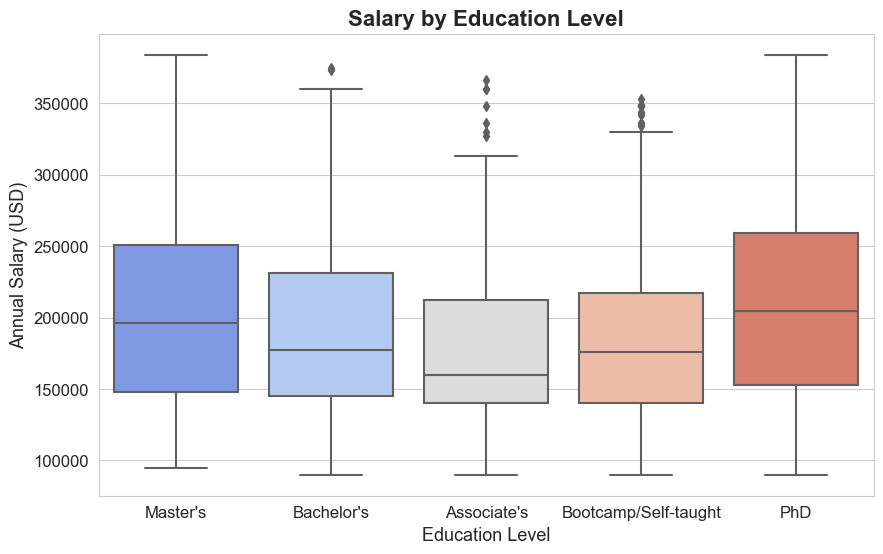

In [48]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="education_required",
    y="annual_salary_usd",
    palette="coolwarm"
)

plt.title("Salary by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Annual Salary (USD)")

plt.show()

**Insight**

- **The "Skill is King" Theory:** The heavy presence of **high-paying outliers** in the **Associate's and Bootcamp** categories proves that elite companies are willing to pay **top dollar for talent** regardless of where they started, provided they can perform at a high level.


## 12. Correlation Heatmap

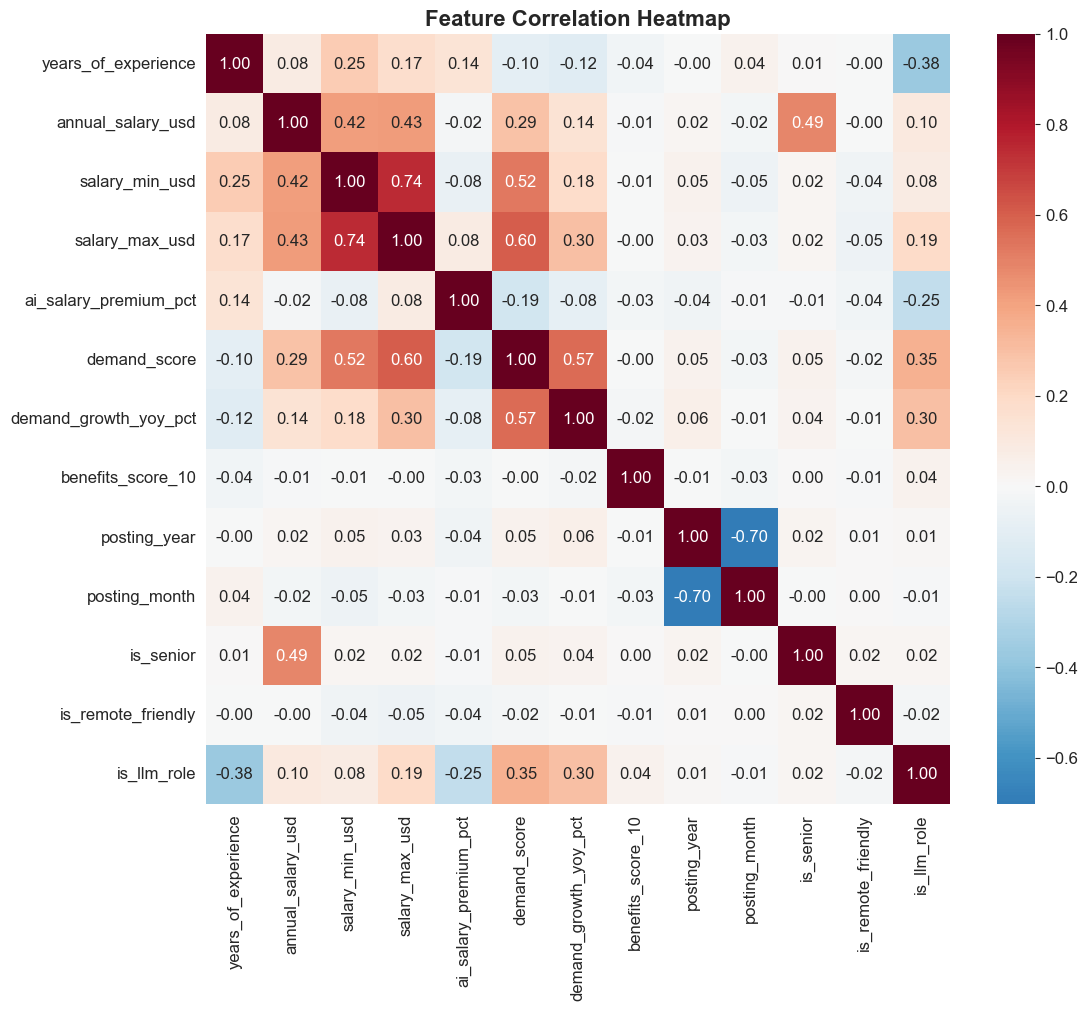

In [49]:
num_df = df.select_dtypes(include="number")

plt.figure(figsize=(12,10))

sns.heatmap(
    num_df.corr(),
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

**Insight**

- There is a much stronger correlation between **salary and being in a senior role (0.49)** than there is with **total years of experience (0.08)**. This suggests the AI market rewards "impact and level" over "time served."

-  There is a significant **negative correlation (-0.38) between years of experience and LLM-specific roles**. This indicates that the most cutting-edge (and high-demand) LLM positions are being filled by talent with fewer years of total experience.

## 13. Benefits vs Salary

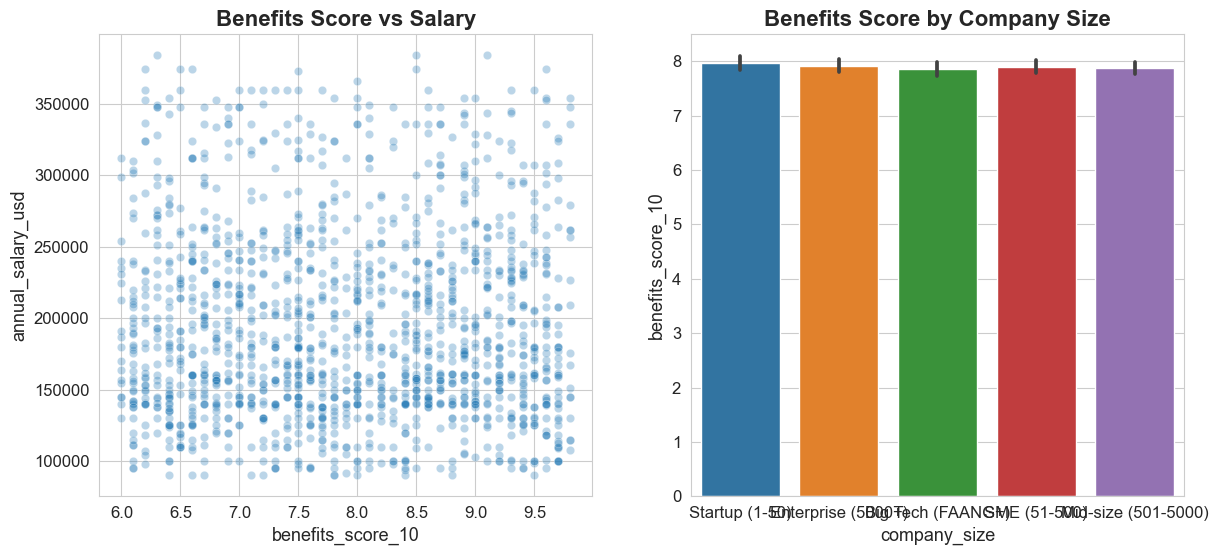

In [50]:
fig, axes = plt.subplots(1,2, figsize=(14,6))

sns.scatterplot(
    data=df,
    x="benefits_score_10",
    y="annual_salary_usd",
    alpha=0.3,
    ax=axes[0]
)

axes[0].set_title("Benefits Score vs Salary")

sns.barplot(
    data=df,
    x="company_size",
    y="benefits_score_10",
    estimator=np.mean,
    ax=axes[1]
)

axes[1].set_title("Benefits Score by Company Size")

plt.show()

**Insight**

- **Benefits are Table Stakes:** In the AI sector, a high quality of benefits is a **market standard, not a differentiator**. Since scores are consistently high across all company sizes, you don't need to sacrifice perks to join a startup, nor do you need to join Big Tech just for the health insurance.

## 14. Job Posting Trends

In [52]:
monthly = (
    df.groupby(["posting_year","posting_month"])
      .agg(avg_salary=("annual_salary_usd","mean"),
           postings=("annual_salary_usd","count"))
      .reset_index()
)

c:\Users\srinithya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\srinithya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\srinithya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\srinithya\AppData\Local\Programs\Python\Pyth

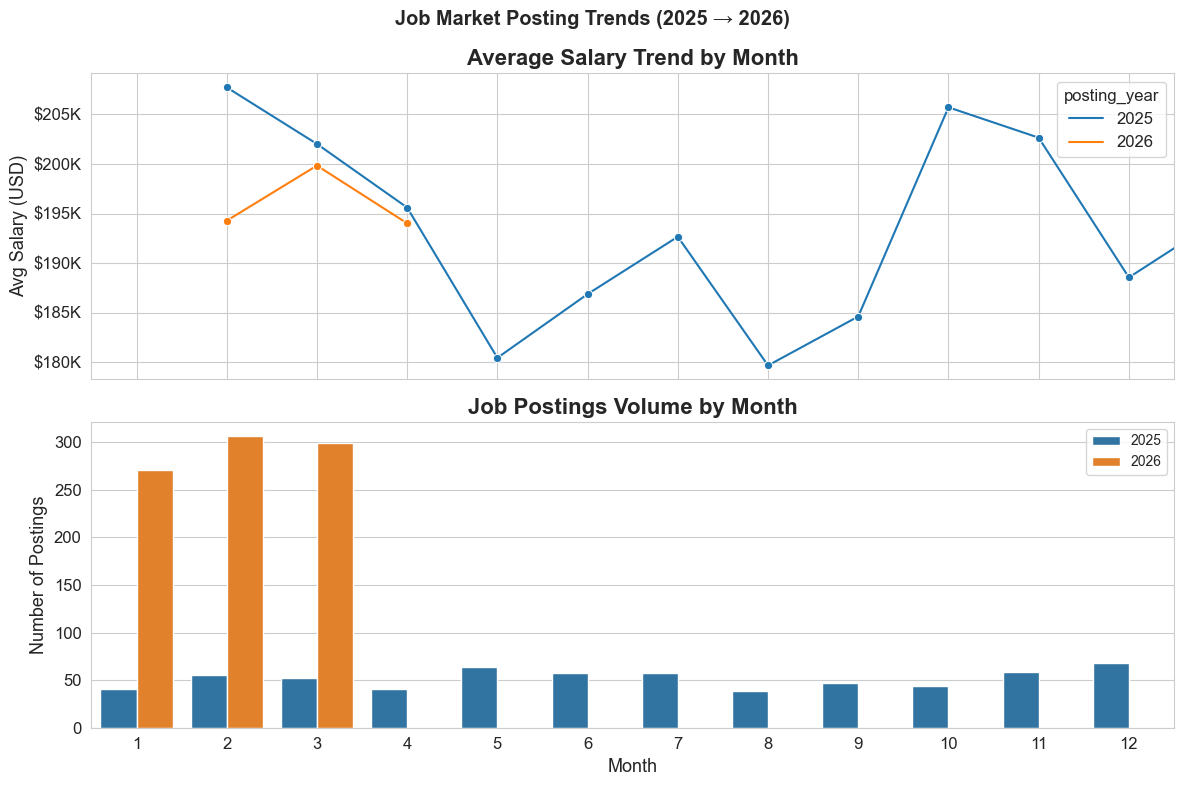

In [60]:
import matplotlib.ticker as mtick

# 1. Setup the 2-row layout
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
plt.suptitle("Job Market Posting Trends (2025 → 2026)", fontweight="bold")

# 2. Top Chart: Salary Line
sns.lineplot(data=monthly, x="posting_month", y="avg_salary", hue="posting_year", 
             marker="o", palette="tab10", ax=ax1)
ax1.set_title("Average Salary Trend by Month")
ax1.set_ylabel("Avg Salary (USD)")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}K'))

# 3. Bottom Chart: Posting Volume Bars
sns.barplot(data=monthly, x="posting_month", y="postings", hue="posting_year",  
            palette="tab10", ax=ax2)
ax2.set_title("Job Postings Volume by Month")
ax2.set_ylabel("Number of Postings")
ax2.set_xlabel("Month")
ax2.legend(loc='upper right', fontsize='small')

# 4. Clean up
plt.tight_layout()
plt.show()


**Insight**

- There is significantly more opportunity now (volume) than there was a year ago, but companies appear to be more disciplined with their salary offers, moving away from the "peak" highs of early 2025.

- The 2025 blue line shows a "rollercoaster" of salary changes throughout the year. If 2026 follows this pattern, we may see another dip in salaries around April/May before a recovery in the fall.


# Executive Takeaway

The **AI job market is shifting from generalists to specialized architects**.

To maximize earning potential:

1. Specialize in **LLMs and infrastructure**
2. Develop **Fine-tuning and Distributed Systems expertise**
3. Target **Automotive, Consulting, or Finance industries**
4. Aim for **Senior titles early rather than relying on tenure**
